[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/arvidl/BMED365-2026/blob/main/Lab3-GenAI-LLM/notebooks/02-transformer-architecture.ipynb)

# Transformer Architecture: The Foundation of Modern AI

**ELMED219 / BMED365 - Lab 3**

Last updated:<br>
2026-01-18, A. Lundervold

---

## 🎯 Learning Objectives

By the end of this notebook, you will be able to:

| Objective | Description | Level |
|-----------|-------------|-------|
| **Understand Self-Attention** | Explain how the attention mechanism allows models to focus on relevant parts of input | Core |
| **Visualize Transformers** | Create and interpret attention weight visualizations | Core |
| **Identify Components** | Recognize the key building blocks of transformer architecture | Core |
| **Apply to Healthcare** | Connect transformer concepts to medical AI applications | Application |
| **Implement Basic Attention** | Code a simplified attention mechanism from scratch | Implementation |

### What You'll Learn

- ✅ **Core Concepts**: Attention mechanism, queries, keys, and values
- ✅ **Architecture**: Multi-head attention, transformer blocks, and scaling
- ✅ **Visualization**: How to interpret attention patterns
- ✅ **Applications**: Real-world uses in medical AI
- ✅ **Hands-on**: Build a simple attention mechanism

### Prerequisites

- Basic Python programming
- Understanding of neural networks (covered in Lab 2)
- Familiarity with medical terminology (helpful but not required)

## Contents

1. [Environment Setup](#1-environment-setup)
2. [What is Attention?](#2-what-is-attention)
3. [Self-Attention in Practice](#3-self-attention-in-practice)
4. [Multi-Head Attention](#4-multi-head-attention)
5. [The Transformer Block](#5-the-transformer-block)
6. [Practical Significance for Healthcare](#6-practical-significance-for-healthcare)

---

## 1. Environment Setup

The code works both locally and in Google Colab.

In [1]:
# =============================================================================
# ENVIRONMENT SETUP: TRANSFORMER ARCHITECTURE NOTEBOOK
# =============================================================================
# This cell sets up all required libraries for exploring transformers.
# Works in both local environment and Google Colab.
# =============================================================================

import sys
import os

# -----------------------------------------------------------------------------
# Step 1: Check execution environment
# -----------------------------------------------------------------------------
IN_COLAB = 'google.colab' in sys.modules

if IN_COLAB:
    print("Running in Google Colab")
    # Install necessary packages if in Colab
    %pip install seaborn torch --quiet
else:
    print("Running in local environment")

# -----------------------------------------------------------------------------
# Step 2: Import standard libraries
# -----------------------------------------------------------------------------
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# -----------------------------------------------------------------------------
# Step 3: Import PyTorch for transformer demonstrations
# -----------------------------------------------------------------------------
try:
    import torch
    import torch.nn as nn
    TORCH_AVAILABLE = True
    print(f"PyTorch version: {torch.__version__}")
except ImportError:
    TORCH_AVAILABLE = False
    print("PyTorch not available - some examples will not run")

# -----------------------------------------------------------------------------
# Step 4: Set random seeds for reproducibility
# -----------------------------------------------------------------------------
# This ensures you get the same results each time you run the notebook
RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)
if TORCH_AVAILABLE:
    torch.manual_seed(RANDOM_SEED)
print(f"Random seed set to {RANDOM_SEED} for reproducibility")

print("\n✅ Environment is configured and ready!")

Running in local environment
PyTorch version: 2.6.0
Random seed set to 42 for reproducibility

✅ Environment is configured and ready!


---

## 2. What is Attention?

**Attention** is a mechanism that allows the model to focus on relevant parts of the input sequence when processing each element.

### The Intuition

Imagine you're reading the sentence:

> "The patient has severe diabetes, and **she** needs insulin treatment."

To understand who "she" refers to, you need to look back at "the patient". This is essentially what attention does - it allows the model to "look back" and connect relevant parts of the text.

### Mathematical Foundation

Attention is calculated with three components:
- **Query (Q)**: What we're looking for
- **Key (K)**: What each element "offers"
- **Value (V)**: The content that is returned

$$\text{Attention}(Q, K, V) = \text{softmax}\left(\frac{QK^T}{\sqrt{d_k}}\right)V$$

---

## 3. Self-Attention in Practice

Let's implement a simplified version of attention to understand how it works.

---

### 🤔 Self-Check Questions: Understanding Attention

Before moving forward, test your understanding:

#### Question 1: Conceptual Understanding
**In your own words, why does a language model need an "attention mechanism"?**

Think about: What problem does attention solve that simpler approaches don't address?

<details>
<summary>💡 Click to reveal answer</summary>

**Answer:**

Traditional approaches process text sequentially or treat all words equally. Attention allows the model to:
- **Focus** on relevant parts of the input when processing each element
- **Capture relationships** between words regardless of distance
- **Weigh importance** dynamically based on context

**Medical Example:** In "The patient has severe diabetes, and she needs insulin treatment":
- To understand "she" → must attend to "patient"
- To understand "insulin" → should attend to "diabetes" and "severe"
- Simple sequential processing misses these long-range dependencies

**Key Insight:** Attention is like a spotlight that the model can direct to relevant information, rather than processing everything uniformly.

</details>

#### Question 2: Technical Components
**What are the three components (Q, K, V) of attention, and what role does each play?**

<details>
<summary>💡 Click to reveal answer</summary>

**Answer:**

1. **Query (Q)** - "What I'm looking for"
   - Represents the current word/position asking questions
   - Example: If processing "insulin", the query asks "what's related to insulin?"

2. **Key (K)** - "What I can offer"
   - Represents what each word in the sequence can provide
   - Example: "diabetes" offers information about a medical condition

3. **Value (V)** - "The actual content"
   - The information that gets retrieved and combined
   - Example: The actual representation/meaning of "diabetes"

**The Mechanism:**
```
Attention(Q, K, V) = softmax(Q · K^T / √d_k) · V
                     ↓           ↓           ↓
                 Compute    Normalize   Weighted
                 similarity to           sum
                            probabilities
```

**Medical Analogy:**
- Query = Doctor's question: "What's causing chest pain?"
- Keys = Patient's information: [symptoms, history, labs]
- Values = Detailed content for each piece of information
- Attention = Which pieces the doctor focuses on

</details>

#### Question 3: Application to Healthcare
**How could attention weights help explain a model's medical predictions?**

<details>
<summary>💡 Click to reveal answer</summary>

**Answer:**

Attention weights provide **interpretability** - we can see what the model focuses on:

**Example: Diagnosis Prediction**
```
Clinical Note: "72yo male with diabetes, hypertension. 
                Presents with severe chest pain, SOB..."

Model predicts: High risk for MI (myocardial infarction)

Attention Visualization Shows:
- Strong attention from "chest pain" → "severe" (0.85)
- Strong attention from "chest pain" → "SOB" (0.78)
- Moderate attention to "diabetes" (0.45) [risk factor]
- Moderate attention to "hypertension" (0.42) [risk factor]
```

**Benefits:**
1. **Validation**: Check if model focuses on clinically relevant information
2. **Trust**: Understand the reasoning process
3. **Error Detection**: Identify when model attends to wrong features
4. **Education**: Learn patterns the model has discovered
5. **Compliance**: Document decision-making process

**Important**: Attention is NOT the same as explanation/causation, but provides insights into the model's information flow.

</details>

#### Question 4: Visualization Interpretation
**Look at the attention heatmap in Section 3. Why does "diabetes" have high attention to "severe"?**

<details>
<summary>💡 Click to reveal answer</summary>

**Answer:**

In the simulated example, "diabetes" and "severe" have high mutual attention because:

1. **Semantic Relationship**: "Severe" is a medical modifier that often describes conditions like diabetes
2. **Co-occurrence Patterns**: The model learns from training data that these words often appear together and are clinically related
3. **Contextual Relevance**: Understanding the severity of diabetes is crucial for treatment decisions

**What This Means:**
- The model has learned that when it sees "diabetes", it should pay attention to its qualifiers
- When it sees "severe", it attends to what's being described as severe
- This relationship helps the model build richer understanding

**In Practice:**
A medical LLM trained on clinical notes learns that:
- "severe diabetes" requires different treatment than "controlled diabetes"
- Severity modifiers are important for diagnosis and treatment planning
- Attention captures these clinical nuances automatically

</details>

---

In [2]:
# =============================================================================
# SIMPLE ATTENTION: THE CORE MECHANISM
# =============================================================================
# This is the fundamental attention operation used in transformers.
# Formula: Attention(Q, K, V) = softmax(Q · K^T) · V
# =============================================================================

def simple_attention(query, keys, values):
    """
    Simplified attention mechanism - the core of transformer architecture.
    
    This implements scaled dot-product attention without the scaling factor
    for simplicity. Real transformers use: softmax(Q·K^T / √d_k) · V
    
    Args:
        query (np.ndarray): Vector representing "what we're looking for"
        keys (np.ndarray): Matrix where each row is "what each element offers"
        values (np.ndarray): Matrix with actual content to retrieve
    
    Returns:
        output (np.ndarray): Weighted sum of values (the attention output)
        weights (np.ndarray): Attention weights showing focus on each position
    
    Medical Analogy:
        Query = Doctor's question: "What relates to chest pain?"
        Keys = Each symptom/finding saying "I might be relevant"
        Values = The actual clinical information
        Output = Combined information weighted by relevance
    """
    # Step 1: Compute similarity between query and all keys (dot product)
    # Higher values = more similar = more relevant
    scores = np.dot(query, keys.T)
    
    # Step 2: Apply softmax to convert to probabilities (sum to 1)
    # This is how attention "focuses" - higher scores get more weight
    weights = np.exp(scores) / np.sum(np.exp(scores))
    
    # Step 3: Weighted sum of values based on attention weights
    # Each value contributes proportionally to its relevance
    output = np.dot(weights, values)
    
    return output, weights

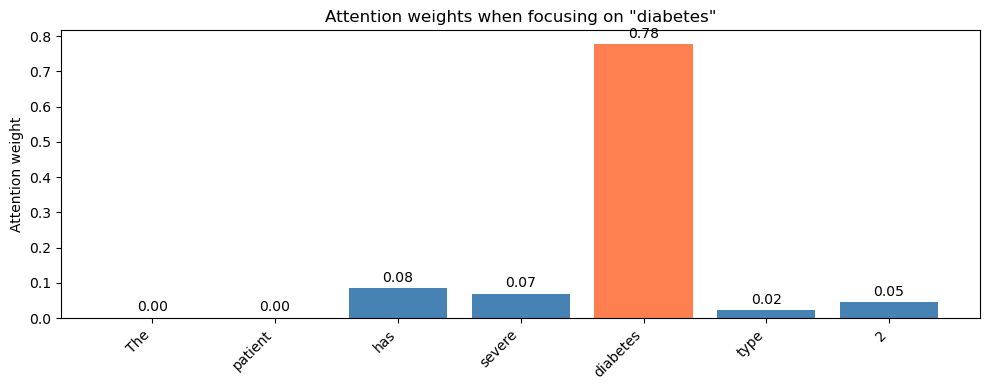


Highest attention: 'diabetes'
Second highest: 'has'


In [3]:
# =============================================================================
# ATTENTION EXAMPLE: MEDICAL SENTENCE
# =============================================================================
# Let's see attention in action with a clinical sentence.
# We'll visualize what the word "diabetes" attends to.
# =============================================================================

# Define a simple medical sentence
words = ["The", "patient", "has", "severe", "diabetes", "type", "2"]

# -----------------------------------------------------------------------------
# Step 1: Create simulated word embeddings
# -----------------------------------------------------------------------------
# In practice, embeddings come from trained models (BERT, GPT, etc.)
np.random.seed(42)  # Reproducibility: same results every run
embedding_dim = 4   # Small dimension for demo (real models use 768+)
word_embeddings = np.random.randn(len(words), embedding_dim)

# -----------------------------------------------------------------------------
# Step 2: Compute attention from "diabetes" to all words
# -----------------------------------------------------------------------------
query_idx = 4  # Index of "diabetes"
query = word_embeddings[query_idx]

# Apply attention function
output, attention_weights = simple_attention(query, word_embeddings, word_embeddings)

# Visualize attention weights
plt.figure(figsize=(10, 4))
colors = ['steelblue' if i != query_idx else 'coral' for i in range(len(words))]
bars = plt.bar(words, attention_weights, color=colors)
plt.title(f'Attention weights when focusing on "{words[query_idx]}"')
plt.ylabel('Attention weight')
plt.xticks(rotation=45, ha='right')

# Add values on the bars
for bar, weight in zip(bars, attention_weights):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.01, 
             f'{weight:.2f}', ha='center', va='bottom', fontsize=10)

plt.tight_layout()
plt.show()

print(f"\nHighest attention: '{words[np.argmax(attention_weights)]}'")
print(f"Second highest: '{words[np.argsort(attention_weights)[-2]]}'")

### Visualization of the Attention Matrix

Let's look at the full attention matrix - how each word "sees" all other words.

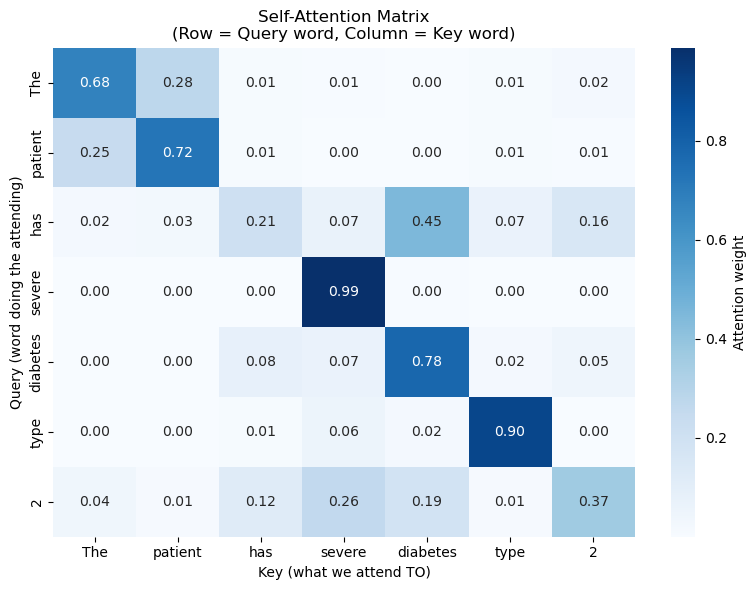

📖 How to read: Each row shows what one word attends to.
   Higher values (darker blue) = stronger attention relationship.


In [4]:
# =============================================================================
# SELF-ATTENTION MATRIX: VISUALIZING ALL WORD RELATIONSHIPS
# =============================================================================
# In self-attention, EVERY word attends to EVERY other word.
# This creates an n×n matrix showing all pairwise relationships.
# =============================================================================

def compute_attention_matrix(embeddings):
    """
    Calculate the full self-attention matrix.
    
    For each word (query), compute attention to all words (keys).
    Result: n×n matrix where entry [i,j] = attention from word i to word j.
    
    Args:
        embeddings: Word embedding matrix (n_words × embedding_dim)
    
    Returns:
        attention_matrix: n×n matrix of attention weights
    """
    n = len(embeddings)
    attention_matrix = np.zeros((n, n))
    
    # For each word as query, compute attention to all words
    for i in range(n):
        _, weights = simple_attention(embeddings[i], embeddings, embeddings)
        attention_matrix[i] = weights
    
    return attention_matrix

# Compute the full attention matrix
attention_matrix = compute_attention_matrix(word_embeddings)

# -----------------------------------------------------------------------------
# Visualize as heatmap - this is how attention is often shown in papers
# -----------------------------------------------------------------------------
plt.figure(figsize=(8, 6))
sns.heatmap(attention_matrix, 
            xticklabels=words, 
            yticklabels=words,
            annot=True,          # Show numbers in cells
            fmt='.2f',           # Format to 2 decimal places
            cmap='Blues',        # Blue colormap (darker = higher attention)
            cbar_kws={'label': 'Attention weight'})
plt.title('Self-Attention Matrix\n(Row = Query word, Column = Key word)')
plt.xlabel('Key (what we attend TO)')
plt.ylabel('Query (word doing the attending)')
plt.tight_layout()
plt.show()

print("📖 How to read: Each row shows what one word attends to.")
print("   Higher values (darker blue) = stronger attention relationship.")

### Reflection

> **Think about**: In a real medical context, which word pairs would you expect high attention between?
> 
> For example: "patient" ↔ "diagnosis", "medication" ↔ "dose", "symptom" ↔ "treatment"

---

## 4. Multi-Head Attention

In practice, transformers use **multiple attention "heads"** that can focus on different aspects of the input simultaneously:

- **Head 1**: Grammatical relations (subject-verb)
- **Head 2**: Semantic connections (symptom-diagnosis)
- **Head 3**: Medical terminology (generic name-brand name)
- **Head 4**: Temporal relations (before-after treatment)

This gives the model richer representations.

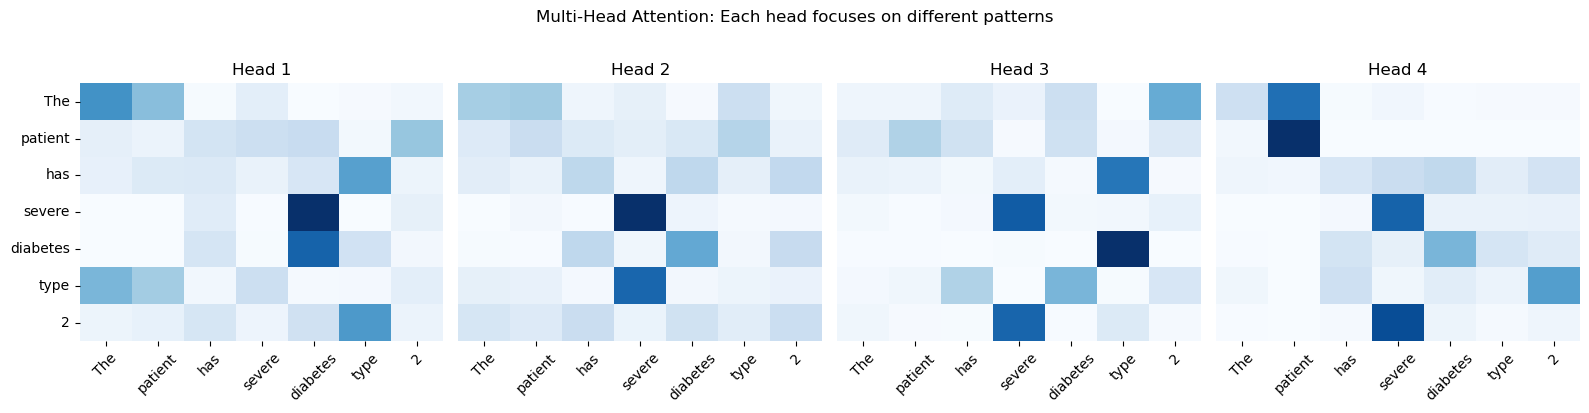


💡 Key Insight: Notice how each head shows a DIFFERENT attention pattern!
   This allows the model to capture multiple types of relationships.


In [5]:
# =============================================================================
# MULTI-HEAD ATTENTION: MULTIPLE PERSPECTIVES
# =============================================================================
# Instead of one attention mechanism, transformers use MULTIPLE "heads"
# running in parallel. Each head learns to focus on different patterns:
#   - Head 1 might focus on syntax (subject-verb relationships)
#   - Head 2 might focus on semantics (related medical terms)
#   - Head 3 might focus on negation or modifiers
# =============================================================================

def multi_head_attention_demo(embeddings, n_heads=4):
    """
    Demonstrate multi-head attention with different random projections.
    
    Each head uses different learned weight matrices (W_q, W_k) to project
    embeddings, resulting in different attention patterns.
    
    Args:
        embeddings: Word embedding matrix
        n_heads: Number of attention heads (typical: 8, 12, or 16)
    """
    n_words, d_model = embeddings.shape
    d_head = d_model  # Simplified: same dimension per head
    
    fig, axes = plt.subplots(1, n_heads, figsize=(16, 4))
    
    for h in range(n_heads):
        # Each head has its own projection matrices
        # These are LEARNED during training to capture different patterns
        np.random.seed(h * 100)  # Different random seed per head
        W_q = np.random.randn(d_model, d_head) * 0.5  # Query projection
        W_k = np.random.randn(d_model, d_head) * 0.5  # Key projection
        
        # Project embeddings through this head's matrices
        Q = embeddings @ W_q  # Queries
        K = embeddings @ W_k  # Keys
        
        # Compute attention scores and weights
        scores = Q @ K.T
        attention = np.exp(scores) / np.exp(scores).sum(axis=1, keepdims=True)
        
        # Visualize this head's attention pattern
        sns.heatmap(attention, ax=axes[h], cmap='Blues', 
                    xticklabels=words, yticklabels=words if h == 0 else False,
                    cbar=False)
        axes[h].set_title(f'Head {h+1}')
        axes[h].tick_params(axis='x', rotation=45)
    
    plt.suptitle('Multi-Head Attention: Each head focuses on different patterns', y=1.02)
    plt.tight_layout()
    plt.show()

# Run the demonstration
multi_head_attention_demo(word_embeddings)

print("\n💡 Key Insight: Notice how each head shows a DIFFERENT attention pattern!")
print("   This allows the model to capture multiple types of relationships.")

---

## 5. The Transformer Block

A complete transformer block consists of:

1. **Multi-Head Self-Attention**
2. **Add & Normalize** (residual connection + layer norm)
3. **Feed-Forward Network**
4. **Add & Normalize**

```
Input
  │
  ├──────────────────┐
  ↓                  │
Multi-Head Attention │
  ↓                  │
  + ←────────────────┘  (Residual Connection)
  ↓
Layer Norm
  │
  ├──────────────────┐
  ↓                  │
Feed-Forward Network │
  ↓                  │
  + ←────────────────┘  (Residual Connection)
  ↓
Layer Norm
  ↓
Output
```

In [6]:
# =============================================================================
# TRANSFORMER BLOCK: THE COMPLETE BUILDING UNIT
# =============================================================================
# A transformer block combines:
#   1. Multi-Head Self-Attention (relate inputs to each other)
#   2. Add & Norm (residual connection + layer normalization)
#   3. Feed-Forward Network (process each position independently)
#   4. Add & Norm (another residual + normalization)
#
# Stack many of these blocks to build powerful models:
#   - BERT-base: 12 blocks
#   - GPT-3: 96 blocks
# =============================================================================

if TORCH_AVAILABLE:
    class SimpleTransformerBlock(nn.Module):
        """
        Simplified transformer block for demonstration.
        
        This is the core building block of ALL modern LLMs.
        BERT, GPT, T5, Med-PaLM - all are built from these blocks.
        
        Args:
            d_model: Dimension of model representations (default: 512)
            n_heads: Number of attention heads (default: 8)
            d_ff: Hidden dimension of feed-forward network (default: 2048)
        """
        
        def __init__(self, d_model=512, n_heads=8, d_ff=2048):
            super().__init__()
            # Multi-head self-attention layer
            self.attention = nn.MultiheadAttention(d_model, n_heads, batch_first=True)
            # Layer normalization for stable training
            self.norm1 = nn.LayerNorm(d_model)
            self.norm2 = nn.LayerNorm(d_model)
            # Feed-forward network (applied to each position)
            self.feed_forward = nn.Sequential(
                nn.Linear(d_model, d_ff),   # Expand to d_ff
                nn.ReLU(),                   # Non-linearity
                nn.Linear(d_ff, d_model)     # Project back to d_model
            )
        
        def forward(self, x):
            # Step 1: Self-attention with residual connection
            attn_output, _ = self.attention(x, x, x)  # Q=K=V=x for self-attention
            x = self.norm1(x + attn_output)           # Add & Normalize
            
            # Step 2: Feed-forward with residual connection
            ff_output = self.feed_forward(x)
            x = self.norm2(x + ff_output)             # Add & Normalize
            
            return x

    # Create and inspect the model
    model = SimpleTransformerBlock(d_model=512, n_heads=8)
    n_params = sum(p.numel() for p in model.parameters())
    
    print(f"✅ Transformer block created with {n_params:,} parameters")
    print(f"\n📦 Architecture:\n{model}")
    print(f"\n💡 Real models stack 12-96 of these blocks!")
else:
    print("⚠️ PyTorch not available - skipping transformer block demo")

✅ Transformer block created with 3,152,384 parameters

📦 Architecture:
SimpleTransformerBlock(
  (attention): MultiheadAttention(
    (out_proj): NonDynamicallyQuantizableLinear(in_features=512, out_features=512, bias=True)
  )
  (norm1): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
  (norm2): LayerNorm((512,), eps=1e-05, elementwise_affine=True)
  (feed_forward): Sequential(
    (0): Linear(in_features=512, out_features=2048, bias=True)
    (1): ReLU()
    (2): Linear(in_features=2048, out_features=512, bias=True)
  )
)

💡 Real models stack 12-96 of these blocks!


### Scaling

Modern language models stack many such blocks:

| Model | Blocks | Attention Heads | Parameters |
|-------|--------|-----------------|------------|
| BERT-base | 12 | 12 | 110M |
| GPT-2 | 12 | 12 | 117M |
| GPT-3 | 96 | 96 | 175B |
| GPT-4 | ~120? | ~96? | ~1.7T? |

---

## 6. Practical Significance for Healthcare

The transformer architecture enables many important applications:

### 1. Clinical Note Summarization
Attention allows the model to identify and focus on the most important parts of long patient records.

### 2. Diagnostic Support
By connecting symptoms to possible diagnoses through attention patterns.

### 3. Drug Interactions
Detect potential drug interactions by relating medications to each other.

### 4. Patient Communication
Explain medical terms in an understandable way by understanding context.

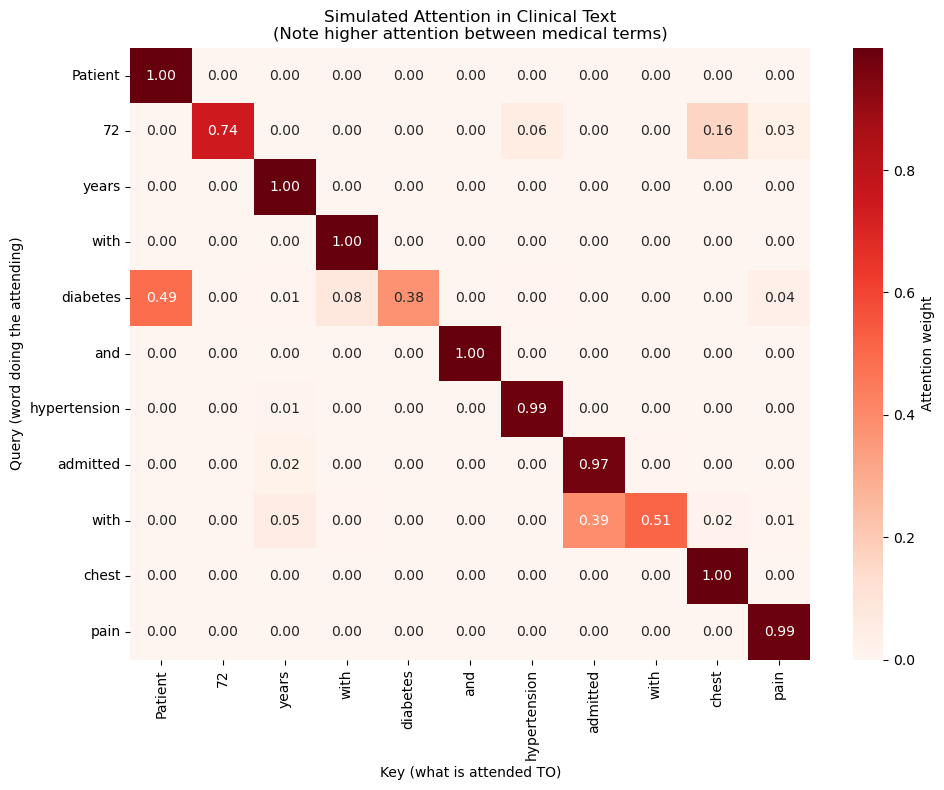


🏥 Clinical AI Insight:
   Notice the higher attention weights between 'diabetes', 'hypertension', and 'pain'
   A real medical LLM learns these relationships from training on clinical notes.

📊 This is how transformers connect risk factors (diabetes, hypertension)
   with presenting symptoms (chest pain) for diagnostic support.


In [7]:
# =============================================================================
# CLINICAL APPLICATION: ATTENTION IN MEDICAL TEXT
# =============================================================================
# Let's see how attention might work on real clinical text.
# In practice, medical LLMs learn to attend strongly between:
#   - Symptoms and diagnoses
#   - Medications and conditions
#   - Risk factors and outcomes
# =============================================================================

# Example clinical note snippet
clinical_text = ["Patient", "72", "years", "with", "diabetes", "and", "hypertension", 
                 "admitted", "with", "chest", "pain"]

# -----------------------------------------------------------------------------
# Simulate learned embeddings
# -----------------------------------------------------------------------------
# Real models learn these from millions of medical documents
np.random.seed(123)  # Reproducibility
clinical_embeddings = np.random.randn(len(clinical_text), 8)

# Simulate that the model has learned meaningful relationships:
# Medical terms (diabetes, hypertension, chest pain) should attend to each other
symptom_indices = [4, 6, 10]  # diabetes, hypertension, pain
for i in symptom_indices:
    for j in symptom_indices:
        if i != j:
            # Add some of embedding j to embedding i → makes them more similar
            clinical_embeddings[i] += 0.3 * clinical_embeddings[j]

# -----------------------------------------------------------------------------
# Calculate and visualize the attention matrix
# -----------------------------------------------------------------------------
clinical_attention = compute_attention_matrix(clinical_embeddings)

plt.figure(figsize=(10, 8))
sns.heatmap(clinical_attention, 
            xticklabels=clinical_text, 
            yticklabels=clinical_text,
            annot=True, 
            fmt='.2f',
            cmap='Reds',
            cbar_kws={'label': 'Attention weight'})
plt.title('Simulated Attention in Clinical Text\n(Note higher attention between medical terms)')
plt.xlabel('Key (what is attended TO)')
plt.ylabel('Query (word doing the attending)')
plt.tight_layout()
plt.show()

# -----------------------------------------------------------------------------
# Interpretation for medical AI
# -----------------------------------------------------------------------------
print("\n🏥 Clinical AI Insight:")
print("   Notice the higher attention weights between 'diabetes', 'hypertension', and 'pain'")
print("   A real medical LLM learns these relationships from training on clinical notes.")
print("\n📊 This is how transformers connect risk factors (diabetes, hypertension)")
print("   with presenting symptoms (chest pain) for diagnostic support.")

---

## Summary

### Key Points

1. **Attention** allows the model to focus on relevant parts of the input
2. **Self-attention** calculates relations between all words in a sequence
3. **Multi-head attention** captures different types of relations simultaneously
4. **Transformer blocks** combine attention with feed-forward networks
5. **Scaling** this architecture gives us today's powerful language models

### Reflection Questions

1. Why do you think the attention mechanism is particularly useful for medical texts?
2. What challenges can arise when using attention on very long documents?
3. How can visualization of attention contribute to explainable AI in medicine?

---

*Next notebook: [03 - LLM Fundamentals](03-llm-fundamentals.ipynb)*

---

## 🎯 Key Takeaways

```
┌──────────────────────────────────────────────────────────────────────────────┐
│              TRANSFORMER ARCHITECTURE: ESSENTIAL INSIGHTS                    │
├──────────────────────────────────────────────────────────────────────────────┤
│                                                                              │
│  🔑 FUNDAMENTAL CONCEPTS                                                     │
│  ═══════════════════════                                                     │
│                                                                              │
│  Attention = Focus Mechanism                                                 │
│  ───────────────────────────                                                 │
│  • Allows model to identify and focus on relevant information                │
│  • Computes relationships between ALL input elements simultaneously          │
│  • More flexible than fixed connections or sequential processing             │
│  • Enables capturing long-range dependencies (crucial for medical text)      │
│                                                                              │
│  The Magic Formula: Attention(Q, K, V)                                       │
│  ───────────────────────────────────                                         │
│  ① Query (Q)   → "What am I looking for?"                                   │
│  ② Key (K)     → "What information do I have?"                              │
│  ③ Value (V)   → "The actual content to retrieve"                           │
│  ④ Similarity  → Q · K^T (dot product)                                      │
│  ⑤ Normalize   → softmax (→ probabilities)                                  │
│  ⑥ Combine     → weighted sum of Values                                     │
│                                                                              │
│  Self-Attention Magic                                                        │
│  ────────────────────                                                        │
│  • Input attends to ITSELF                                                   │
│  • Every word can relate to every other word                                 │
│  • Parallel processing (much faster than RNNs!)                              │
│  • Captures context from entire sequence                                     │
│                                                                              │
│  Medical Example:                                                            │
│  "Patient has severe diabetes, and she needs insulin."                       │
│   └── "she" attends to "Patient" (high weight)                               │
│   └── "insulin" attends to "diabetes" (high weight)                          │
│   └── Model understands relationships automatically                          │
│                                                                              │
├──────────────────────────────────────────────────────────────────────────────┤
│                                                                              │
│  ⚙️ ARCHITECTURE BUILDING BLOCKS                                             │
│  ════════════════════════════                                                │
│                                                                              │
│  Multi-Head Attention = Multiple Perspectives                                │
│  ───────────────────────────────────────────                                 │
│  • Run h attention mechanisms in parallel (typically 8-96 heads)             │
│  • Each head learns DIFFERENT types of relationships:                        │
│    - Head 1: Syntactic structure (subject-verb-object)                       │
│    - Head 2: Semantic similarity (related medical terms)                     │
│    - Head 3: Long-range dependencies (cross-sentence refs)                   │
│  • Concatenate outputs → Project back → Richer representation                │
│                                                                              │
│  Think: Multiple specialists reviewing same patient case                     │
│                                                                              │
│  Transformer Block = Complete Processing Unit                                │
│  ──────────────────────────────────────────                                  │
│  ┌─────────────────────────────────────────────┐                             │
│  │  Input                                      │                             │
│  │    ↓                                        │                             │
│  │  Multi-Head Attention ←─────────────┐       │                             │
│  │    ↓                                │       │                             │
│  │  Add & Norm (Residual) ←────────────┘       │                             │
│  │    ↓                                        │                             │
│  │  Feed-Forward Network ←──────────────┐      │                             │
│  │    ↓                                 │      │                             │
│  │  Add & Norm (Residual) ←─────────────┘      │                             │
│  │    ↓                                        │                             │
│  │  Output                                     │                             │
│  └─────────────────────────────────────────────┘                             │
│                                                                              │
│  Components:                                                                 │
│  • Attention: Relate inputs to each other                                    │
│  • Feed-Forward: Process each position independently (adds depth)            │
│  • Residual (+): Shortcut connections for gradient flow                      │
│  • LayerNorm: Stabilize training                                             │
│                                                                              │
│  Scaling to Modern LLMs                                                      │
│  ──────────────────────                                                      │
│  Stack many transformer blocks:                                              │
│  • BERT-base: 12 layers, 12 heads → 110M params                              │
│  • GPT-2: 48 layers, 16 heads → 1.5B params                                  │
│  • GPT-3: 96 layers, 96 heads → 175B params                                  │
│  • GPT-4: ~120 layers?, ~96 heads? → ~1.7T params?                           │
│                                                                              │
│  More layers × More heads × Bigger dimensions = More Powerful Model          │
│                                                                              │
├──────────────────────────────────────────────────────────────────────────────┤
│                                                                              │
│  🏥 MEDICAL AI APPLICATIONS                                                  │
│  ═══════════════════════                                                     │
│                                                                              │
│  Clinical Note Processing                                                    │
│  ────────────────────────                                                    │
│  ✓ Summarize patient history (attention finds key events)                    │
│  ✓ Extract diagnoses & medications (attend to medical entities)              │
│  ✓ Link symptoms to conditions (model relationships)                         │
│  ✓ Generate discharge summaries (autoregressive generation)                  │
│                                                                              │
│  Medical Literature & Knowledge                                              │
│  ──────────────────────────────                                              │
│  ✓ Answer questions from research papers (attention finds evidence)          │
│  ✓ Summarize treatment guidelines (compress long documents)                  │
│  ✓ Find drug interactions (relate medications)                               │
│  ✓ Literature-based discovery (connect disparate findings)                   │
│                                                                              │
│  Diagnostic Support & Decision Making                                        │
│  ─────────────────────────────────                                           │
│  ✓ Relate symptoms to diagnoses (attention weights = relevance)              │
│  ✓ Suggest relevant tests (understand clinical workflow)                     │
│  ✓ Predict outcomes (model temporal sequences)                               │
│  ✓ Drug interaction warnings (attend to medication combinations)             │
│                                                                              │
│  Explainability Through Attention                                            │
│  ──────────────────────────────────                                          │
│  ✓ Visualize what model focuses on                                           │
│  ✓ Validate clinical reasoning                                               │
│  ✓ Identify potential errors or biases                                       │
│  ✓ Build trust in AI predictions                                             │
│  ⚠ Caveat: Attention ≠ Explanation, but provides insights                    │
│                                                                              │
├──────────────────────────────────────────────────────────────────────────────┤
│                                                                              │
│  💡 PRACTICAL INSIGHTS                                                       │
│  ════════════════════                                                        │
│                                                                              │
│  Why Transformers Won the AI Race                                            │
│  ─────────────────────────────────                                           │
│  ✓ Parallelization: Process entire sequence at once → Faster training        │
│  ✓ Long-range deps: Direct connections between any positions                 │
│  ✓ Scalability: Bigger models = better performance (scaling laws)            │
│  ✓ Versatility: Same architecture for NLP, vision, audio, etc.               │
│  ✓ Transfer learning: Pre-train once → Fine-tune for many tasks              │
│                                                                              │
│  RNNs (Sequential)    vs    Transformers (Parallel)                          │
│  Process word-by-word      Process all words simultaneously                  │
│  Forget long sequences     Remember entire context                           │
│  Slow to train             Fast to train (GPU-friendly)                      │
│  Hard to scale             Easy to scale                                     │
│                                                                              │
│  Understanding Attention Visualizations                                      │
│  ──────────────────────────────────────                                      │
│  Heatmap interpretation:                                                     │
│  • Dark colors (high values) = Strong attention                              │
│  • Light colors (low values) = Weak attention                                │
│  • Diagonal = Self-attention to same word                                    │
│  • Off-diagonal patterns = Learned relationships                             │
│                                                                              │
│  What to look for:                                                           │
│  • Do medical terms attend to each other?                                    │
│  • Do pronouns attend to their referents?                                    │
│  • Do modifiers attend to what they describe?                                │
│                                                                              │
│  From Architecture to Application                                            │
│  ─────────────────────────────────                                           │
│  Same underlying architecture powers:                                        │
│  • ChatGPT (conversational AI)                                               │
│  • BERT (text understanding)                                                 │
│  • GPT-4 (general intelligence?)                                             │
│  • Med-PaLM (medical QA)                                                     │
│  • Copilot (code generation)                                                 │
│                                                                              │
│  Differences come from:                                                      │
│  • Training data (general vs. domain-specific)                               │
│  • Training objective (masked LM vs. causal LM)                              │
│  • Model size (parameters, context window)                                   │
│  • Fine-tuning (task-specific adaptation)                                    │
│                                                                              │
└──────────────────────────────────────────────────────────────────────────────┘
```

### 🎓 What You've Mastered

**Core Concepts:**
- ✅ Attention mechanism and its three components (Q, K, V)
- ✅ How attention enables focusing on relevant information
- ✅ Self-attention: input attending to itself
- ✅ Attention weights as learned relevance scores

**Architecture:**
- ✅ Multi-head attention for multiple perspectives
- ✅ Transformer block structure and components
- ✅ Role of residual connections and normalization
- ✅ How stacking blocks creates powerful models

**Implementation:**
- ✅ Building basic attention mechanism from scratch
- ✅ Visualizing attention patterns
- ✅ Interpreting attention weights

**Applications:**
- ✅ Clinical NLP and medical text processing
- ✅ Diagnostic support and decision making
- ✅ Explainability through attention visualization

### 🔄 Connection to Other Concepts

**From Lab 2 (Deep Learning):**
- Neural networks → Transformers build on feed-forward networks
- CNNs → Attention is like learnable, data-dependent convolution
- Training → Same backpropagation, but attention adds complexity

**To Next Labs:**
- **Lab 3, Notebook 03**: LLM Fundamentals → Training large transformers
- **Lab 3, Notebook 04**: Prompt Engineering → Using transformers effectively
- **Lab 3, Notebook 05**: XAI → Deeper into attention for explanation
- **Lab 3, Notebook 06**: Ethics → Responsible use of powerful models

### 🎯 Next Steps in Your Learning Journey

**To deepen understanding:**
1. Read the "Attention Is All You Need" paper (Vaswani et al., 2017)
2. Explore interactive transformer visualizations (BertViz, Transformer Explainer)
3. Implement attention from scratch in PyTorch
4. Experiment with Hugging Face pre-trained models

**For medical AI:**
1. Try Clinical BERT on medical text
2. Explore Med-PaLM and medical question answering
3. Fine-tune a transformer on medical datasets (MIMIC-III, i2b2)
4. Study evaluation of clinical NLP systems

**Practical skills:**
- You can now read and understand transformer papers
- You understand the architecture behind ChatGPT, BERT, GPT-4
- You can interpret attention visualizations
- You're ready for advanced LLM topics

### 💭 Reflection Questions

Before moving on, consider:

1. **Understanding**: Can you explain to a colleague how attention works?
2. **Application**: Can you identify 3 medical use cases where attention would be valuable?
3. **Limitations**: What are potential challenges in using transformers for medical AI?
4. **Next**: What aspect of transformers do you want to explore more deeply?

---

---

## 📚 Glossary of Key Terms

### 🎯 Core Attention Concepts

| Term | Definition | Why It Matters |
|------|------------|----------------|
| **Attention** | Mechanism allowing model to focus on relevant input parts | Enables capturing long-range dependencies without sequential processing |
| **Query (Q)** | Vector representing "what we're looking for" | Determines what information to retrieve |
| **Key (K)** | Vector representing "what each element offers" | Helps match queries to relevant information |
| **Value (V)** | Actual content/information to be retrieved | What gets returned after attention weighting |
| **Attention Weights** | Normalized scores showing relationship strength | Indicates which inputs are most relevant (0-1 scale) |
| **Self-Attention** | Attention where input attends to itself | Allows modeling relationships within a single sequence |
| **Softmax** | Function converting scores to probabilities | Ensures attention weights sum to 1.0 |
| **Scaled Dot-Product** | Q·K^T / √d_k formula | Scaling factor (√d_k) prevents exploding gradients |

### 🏗️ Architecture Components

| Term | Definition | Purpose |
|------|------------|---------|
| **Multi-Head Attention** | Multiple attention mechanisms in parallel | Captures different types of relationships simultaneously |
| **Attention Head** | Single attention mechanism in multi-head attention | Each head specializes in different patterns |
| **Transformer Block** | Complete processing unit: attention + feed-forward + normalization | Core building block; stack many to build deep models |
| **Feed-Forward Network** | 2-layer MLP processing each position independently | Adds non-linearity and computational depth |
| **Layer Normalization** | Normalize activations across features | Stabilizes training, enables deeper models |
| **Residual Connection** | Skip connection adding input to output | Prevents vanishing gradients, improves gradient flow |
| **Positional Encoding** | Information about token position in sequence | Injects order information (attention has no built-in order) |

### 📏 Model Parameters

| Term | Definition | Typical Values |
|------|------------|----------------|
| **d_model** | Dimension of model's internal representations | 512, 768, 1024, 12288 |
| **d_k / d_q / d_v** | Dimensions of key/query/value vectors | Usually d_model / num_heads |
| **d_ff** | Feed-forward network hidden dimension | Usually 4 × d_model |
| **num_heads** | Number of parallel attention heads | 8, 12, 16, 96 |
| **num_layers** | Number of transformer blocks stacked | 6, 12, 24, 96+ |
| **Context Window** | Maximum sequence length | 512, 2048, 4096, 100K+ tokens |
| **Parameters** | Total trainable numbers in model | 110M (BERT-base) to 1.7T+ (GPT-4) |

### 🤖 Model Architectures

| Term | Type | Description | Parameters |
|------|------|-------------|------------|
| **BERT** | Encoder-only | Bidirectional representations for understanding | 110M-340M |
| **GPT** | Decoder-only | Autoregressive generation | 117M-175B+ |
| **T5** | Encoder-Decoder | Text-to-text framework | 60M-11B |
| **BART** | Encoder-Decoder | Denoising autoencoder | 140M-400M |
| **Transformer-XL** | Decoder-only | Extended context via recurrence | 151M-257M |
| **Med-PaLM** | Decoder-only | Medical question answering | 540B |
| **Clinical BERT** | Encoder-only | BERT pre-trained on clinical notes | 110M |

### 🏥 Medical AI Applications

| Application | Description | Example Tasks |
|-------------|-------------|---------------|
| **Clinical NLP** | Natural language processing for medical text | Extract diagnoses, medications, lab results from notes |
| **Medical Coding** | Automatic assignment of ICD/CPT codes | Convert clinical notes to billing/research codes |
| **Literature Mining** | Extract knowledge from research papers | Find treatment evidence, drug interactions |
| **Report Generation** | Automated creation of medical reports | Radiology findings, discharge summaries |
| **Question Answering** | Answer medical questions from text | Clinical decision support, patient education |
| **Summarization** | Condense long medical documents | Summarize patient history, research papers |
| **Named Entity Recognition** | Identify medical entities in text | Find diseases, drugs, procedures, symptoms |
| **Relation Extraction** | Identify relationships between entities | Link symptoms to diagnoses, drugs to side effects |

### 🔬 Training Concepts

| Term | Definition | Purpose |
|------|------------|---------|
| **Pre-training** | Initial training on large general corpus | Learn general language patterns |
| **Fine-tuning** | Training on task-specific data | Adapt general model to specific medical domain |
| **Transfer Learning** | Apply knowledge from one task to another | Leverage pre-trained models for medical tasks |
| **Masked Language Modeling** | Predict masked words (BERT-style) | Learn bidirectional context |
| **Causal Language Modeling** | Predict next word (GPT-style) | Learn to generate coherent text |
| **Few-Shot Learning** | Learn from small number of examples | Useful when labeled medical data is limited |
| **Zero-Shot Learning** | Perform task without specific training | Rely on general language understanding |

### 📊 Evaluation Metrics

| Metric | Measures | Used For |
|--------|----------|----------|
| **Perplexity** | How surprised model is by test data | Language model quality (lower = better) |
| **BLEU** | Overlap between generated and reference text | Machine translation, summarization |
| **ROUGE** | Recall-oriented overlap | Summarization quality |
| **F1 Score** | Harmonic mean of precision and recall | Classification, entity recognition |
| **Exact Match** | Percentage of perfect predictions | Question answering |
| **Human Evaluation** | Expert assessment of outputs | Clinical validity, safety |

### 💡 Important Distinctions

| Concept A | vs | Concept B | Key Difference |
|-----------|-----|-----------|----------------|
| **Encoder** | vs | **Decoder** | Bidirectional vs. Autoregressive |
| **Attention** | vs | **Self-Attention** | General mechanism vs. Input-to-input |
| **Single-Head** | vs | **Multi-Head** | One perspective vs. Multiple perspectives |
| **Pre-training** | vs | **Fine-tuning** | General learning vs. Task-specific adaptation |
| **Embedding** | vs | **Hidden State** | Input representation vs. Internal representation |
| **Attention Weight** | vs | **Attention Output** | Relevance scores vs. Weighted combination |

---

### 📖 Quick Reference: Attention Formula

```
Attention(Q, K, V) = softmax(Q·K^T / √d_k) · V

Where:
- Q·K^T computes similarity between queries and keys
- √d_k scales the scores to prevent large values
- softmax converts scores to probabilities (sum to 1)
- ·V computes weighted sum of values

In practice:
1. Q, K, V = Linear transformations of input
2. Scores = Q @ K.T / sqrt(d_k)  
3. Weights = softmax(Scores)
4. Output = Weights @ V
```

### 🎯 Remember

**The Attention Mechanism in 3 Steps:**
1. **Compare**: Compute similarity between query and all keys
2. **Weight**: Convert similarities to probabilities with softmax  
3. **Combine**: Take weighted sum of values

**Multi-Head Attention:**
- Run multiple attention mechanisms in parallel
- Each head learns different relationships
- Concat all outputs and project back

**Transformer Block:**
- Multi-head attention layer (relate inputs)
- Feed-forward network (process independently)
- Add residual connections and layer norms
- Stack many blocks for deep models

---

---

## 📖 Further Reading & Resources

### 📄 Seminal Papers (Must-Reads)

1. **⭐ "Attention Is All You Need"** (Vaswani et al., 2017)
   - The paper that started it all
   - Introduced the transformer architecture
   - [ArXiv Link](https://arxiv.org/abs/1706.03762)
   - **Why read it:** Understand the foundation of all modern LLMs
   - **Difficulty:** ⭐⭐⭐ (Medium - mathematical)

2. **"BERT: Pre-training of Deep Bidirectional Transformers for Language Understanding"** (Devlin et al., 2018)
   - Bidirectional transformers
   - Masked language modeling
   - [ArXiv Link](https://arxiv.org/abs/1810.04805)
   - **Why read it:** Learn about encoder-only transformers
   - **Difficulty:** ⭐⭐ (Accessible)

3. **"Language Models are Few-Shot Learners"** (Brown et al., 2020)
   - GPT-3 and scaling laws
   - In-context learning
   - [ArXiv Link](https://arxiv.org/abs/2005.14165)
   - **Why read it:** Understand modern large language models
   - **Difficulty:** ⭐⭐⭐ (Medium)

### 🏥 Medical AI with Transformers

1. **"Publicly Available Clinical BERT Embeddings"** (Alsentzer et al., 2019)
   - BERT pre-trained on MIMIC-III clinical notes
   - [ArXiv Link](https://arxiv.org/abs/1904.03323)
   - **Application:** Clinical NLP, EHR analysis

2. **"Large Language Models Encode Clinical Knowledge"** (Singhal et al., 2023)
   - Med-PaLM 2: Medical question answering at expert level
   - [ArXiv Link](https://arxiv.org/abs/2305.09617)
   - **Application:** Clinical QA, diagnosis support

### 🎓 Educational Resources & Tutorials

1. **⭐ The Illustrated Transformer** (Jay Alammar)
   - Visual, intuitive explanation
   - Step-by-step breakdown
   - [Blog Link](http://jalammar.github.io/illustrated-transformer/)
   - **Perfect for:** Visual learners, first-time learners
   - **Time:** 30-45 minutes

2. **⭐ Annotated Transformer** (Harvard NLP)
   - Line-by-line implementation in PyTorch
   - Executable code with explanations
   - [Link](http://nlp.seas.harvard.edu/annotated-transformer/)
   - **Perfect for:** Learning by implementing
   - **Time:** 2-3 hours

3. **Stanford CS224N: Natural Language Processing**
   - University course materials
   - Lecture videos and slides on transformers
   - [Course Website](http://web.stanford.edu/class/cs224n/)
   - **Lecture 9:** Transformers and Self-Attention

### 🎥 Video Lectures & Tutorials

1. **"Attention for Neural Networks"** - StatQuest
   - Very accessible introduction
   - [YouTube](https://www.youtube.com/watch?v=PSs6nxngL6k)
   - **Length:** ~20 minutes

2. **"Let's build GPT"** - Andrej Karpathy
   - Complete implementation walkthrough
   - [YouTube](https://www.youtube.com/watch?v=kCc8FmEb1nY)
   - **Length:** 2 hours
   - **Level:** Advanced

### 💻 Code & Interactive Tools

1. **⭐ Hugging Face Transformers**
   - Industry-standard transformer library
   - Pre-trained models for immediate use
   - [Documentation](https://huggingface.co/docs/transformers/)
   - [GitHub](https://github.com/huggingface/transformers)

2. **⭐ BertViz** - Visualize Attention
   - Interactive attention visualization tool
   - [GitHub](https://github.com/jessevig/bertviz)
   - [Demo Notebook](https://colab.research.google.com/drive/1hXIQ77A4TYS4y3UthWF-Ci7V7vVUoxmQ)

3. **Transformer Explainer**
   - Interactive, in-browser visualization
   - No installation required
   - [Website](https://poloclub.github.io/transformer-explainer/)

### 📚 Books

1. **"Natural Language Processing with Transformers"** (Tunstall, von Werra, Wolf)
   - Comprehensive practical guide
   - O'Reilly Media, 2022
   - **Best for:** Practical applications

2. **"Dive into Deep Learning"** (Zhang et al.)
   - Interactive deep learning book
   - Chapter 11: Attention Mechanisms
   - [Free Online](https://d2l.ai/)

### 🗂️ Datasets for Practice

**Medical:**
- **MIMIC-III**: ICU patient records [PhysioNet](https://physionet.org/content/mimiciii/)
- **i2b2**: Clinical NLP challenges [i2b2.org](https://www.i2b2.org/NLP/)
- **MedQA**: Medical exam questions [GitHub](https://github.com/jind11/MedQA)

**General NLP:**
- **GLUE**: Language understanding benchmark
- **SQuAD**: Reading comprehension

### 🎯 Learning Paths

**Beginner Path (Weeks 1-2):**
1. Watch: "Attention for Neural Networks" (StatQuest)
2. Read: "The Illustrated Transformer"
3. Try: BertViz visualization tool
4. Practice: Work through this notebook thoroughly

**Intermediate Path (Weeks 3-4):**
1. Read: "Attention Is All You Need" paper
2. Watch: Andrej Karpathy's "Let's build GPT"
3. Code: Implement attention from scratch
4. Explore: Hugging Face Transformers library

**Medical AI Specialization:**
1. Study: Clinical BERT and Med-PaLM papers
2. Dataset: Explore MIMIC-III or i2b2
3. Practice: Medical NER and relation extraction
4. Ethics: Study bias and fairness in medical AI

### 🗺️ Your Learning Roadmap

```
Current Position: ✅ Transformer Architecture Fundamentals
                     You are here! 👆

Next Stops:
│
├─ 📍 Immediate Next (This Course):
│  ├─ Notebook 03: LLM Fundamentals
│  ├─ Notebook 04: Prompt Engineering
│  ├─ Notebook 05: Explainable AI
│  └─ Notebook 06: AI Ethics
│
├─ 📍 Deepen Understanding:
│  ├─ Implement attention from scratch
│  ├─ Read "Attention Is All You Need"
│  ├─ Explore transformer variants
│  └─ Fine-tune models on domain data
│
└─ 📍 Medical AI Specialization:
   ├─ Study Clinical BERT
   ├─ Work with medical datasets
   ├─ Medical NLP tasks (NER, RE, QA)
   └─ Evaluation & validation
```

### 💡 Study Tips

1. **Start visual:** Use "Illustrated Transformer" before diving into papers
2. **Code along:** Don't just read - implement concepts yourself
3. **Use interactive tools:** BertViz and Transformer Explainer for intuition
4. **Build projects:** Best way to truly understand
5. **Join communities:** Ask questions, share learnings

### ✅ Resource Checklist

Essential (complete these first):
- [ ] The Illustrated Transformer (30 min)
- [ ] This notebook with all exercises (2-3 hours)
- [ ] BertViz visualization (30 min)
- [ ] "Attention Is All You Need" paper (2-3 hours)

Highly Recommended:
- [ ] Annotated Transformer implementation
- [ ] Hugging Face Transformers tutorial
- [ ] Andrej Karpathy's GPT video

For Medical AI:
- [ ] Clinical BERT paper
- [ ] Med-PaLM papers
- [ ] Explore MIMIC-III dataset

---

**Remember:** Understanding transformers deeply takes time. Start with visualizations and intuition, then gradually move to implementation and theory!

---